In [7]:
## Fig3：肿瘤对照混杂。全程去掉 GSE241556。
## A 旭日  B 相关  C 堆叠  D 主H2  E 其余H2  F 全组织DE+通路
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggsci)
library(patchwork)
library(scales)
library(data.table)
library(jsonlite)
library(ggnewscale)
library(ggsignif)

root <- "/home/data/tanglei01/project/Prostate_atlas"
outd <- file.path(root, "output/12")
dir.create(outd, recursive = TRUE, showWarnings = FALSE)

drop_gse <- "GSE241556"
type3 <- c("Normal", "Normal_DB", "Naive_BPH")
type4 <- c("Normal", "Normal_DB", "Naive_BPH", "Naive_PC")
type_lab <- c(Normal = "Normal", Normal_DB = "Normal DB",
              Naive_BPH = "BPH", Naive_PC = "Naive PC")
gse_lab <- c(GSE166782 = "Guo", GSE179615 = "Strand", GSE181294 = "Hirz",
             GSE185344 = "Hurley", GSE193337 = "GSE193337")
h2_keep <- c("Hillock cell", "Basal cell", "Club cell", "Luminal cell",
             "CD8 T cell", "Macrophage", "Fibroblast")
h2_lab <- c(`Hillock cell` = "Hillock", `Basal cell` = "Basal",
            `Club cell` = "Club", `Luminal cell` = "Luminal",
            `CD8 T cell` = "CD8", Macrophage = "Macrophage",
            Fibroblast = "Fibroblast", Other = "Other")
feat_def <- list(
  Hillock = list(col = "celltype_manual_H2", val = "Hillock cell"),
  Basal   = list(col = "celltype_manual_H2", val = "Basal cell"),
  Club    = list(col = "celltype_manual_H2", val = "Club cell"),
  CD8     = list(col = "celltype_manual_H2", val = "CD8 T cell"),
  M2      = list(col = "celltype_manual_H3",
                 val = "MRC1+CD163+ M2-like tissue-remodeling macrophage"),
  `IL6+LIF` = list(col = "celltype_manual_H3",
                   val = "IL6+LIF+ inflammatory fibroblast")
)
cols_type <- setNames(substr(pal_d3("category20")(4), 1, 7),
                      c("Normal", "Normal_DB", "Naive_BPH", "Naive_PC"))
cols_h2 <- setNames(substr(pal_d3("category20")(8), 1, 7), names(h2_lab))
th <- theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", size = 13),
        legend.title = element_blank())
star_of <- function(p) {
  ifelse(is.na(p), "",
         ifelse(p < 0.001, "***", ifelse(p < 0.01, "**", ifelse(p < 0.05, "*", "ns"))))
}
lab_feat <- function(x) {
  vapply(as.character(x), function(z) {
    z <- sub("^[A-Za-z0-9]+[+-]([A-Za-z0-9]+[+-])*\\s*", "", z)
    if (grepl(" cell$", z)) {
      stem <- sub(" cell$", "", z)
      if (!grepl(" ", stem)) return(paste0(stem, "\ncell"))
      return(sub("\\s+(\\S+ cell)$", "\n\\1", z))
    }
    z
  }, character(1), USE.NAMES = FALSE)
}
mw_p <- function(a, b) {
  a <- a[is.finite(a)]; b <- b[is.finite(b)]
  if (length(a) < 3 || length(b) < 3) return(NA_real_)
  wilcox.test(a, b, exact = FALSE)$p.value
}
kw_p <- function(a, g) {
  ok <- is.finite(a)
  if (length(unique(as.character(g[ok]))) < 3L) return(NA_real_)
  kruskal.test(a[ok] ~ g[ok])$p.value
}

In [8]:
obs <- fread(file.path(root, "vis/data/processed/scrna/QC_fin.obs.csv.gz"),
             select = c("sample.ID", "GSE.ID", "type",
                        "celltype_manual_H1", "celltype_manual_H2",
                        "celltype_manual_H3"))
obs <- obs[GSE.ID != drop_gse]
obs[, comp := fifelse(celltype_manual_H1 == "Epithelial cell",
                      "Epithelium", "Microenvironment")]
samp <- unique(obs[, .(sample.ID, GSE.ID, type)])
print(table(samp$type))
frac_one <- function(col, val, types = type4) {
  d <- obs[type %in% types]
  tot <- d[, .(n_tot = .N), by = sample.ID]
  hit <- d[get(col) == val, .(n_hit = .N), by = sample.ID]
  out <- merge(tot, hit, by = "sample.ID", all.x = TRUE)
  out[is.na(n_hit), n_hit := 0L]
  out[, frac := n_hit / n_tot]
  merge(out, samp, by = "sample.ID")[type %in% types]
}
## 隔室内部比：上皮 / 上皮，微环境 / 微环境。只去 GSE241556。
frac_in_comp <- function(col, val, types = type3) {
  d <- obs[type %in% types]
  native <- unique(d[get(col) == val, comp])
  if (length(native) != 1L) stop("feat not in one compartment: ", val)
  tot <- d[comp == native, .(n_den = .N), by = sample.ID]
  hit <- d[get(col) == val, .(n_hit = .N), by = sample.ID]
  out <- merge(tot, hit, by = "sample.ID", all.x = TRUE)
  out[is.na(n_hit), n_hit := 0L]
  out[, frac := n_hit / n_den]
  out[, comp := native]
  merge(out, samp, by = "sample.ID")[type %in% types]
}
pairs_nb <- list(
  c("Normal", "Normal_DB"),
  c("Normal_DB", "Naive_BPH"),
  c("Normal", "Naive_BPH")
)
br_of <- function(dat, labs, pairs = pairs_nb) {
  br_lift <- 1.22; br_step <- 0.16
  rbindlist(lapply(levels(dat$feature), function(ft) {
    d <- dat[feature == ft]
    ymax <- max(d$frac, na.rm = TRUE)
    rbindlist(lapply(seq_along(pairs), function(i) {
      a <- pairs[[i]][1]; b <- pairs[[i]][2]
      p <- mw_p(d$frac[d$type == a], d$frac[d$type == b])
      data.table(
        feature = ft,
        xmin = match(a, type3), xmax = match(b, type3),
        y = ymax * (br_lift + br_step * (i - 1)),
        dy = ymax * 0.04,
        star = star_of(p)
      )
    }))
  }))[, feature := factor(as.character(feature), levels = labs)]
}


  5aTreat_BPH Cribriform_PC        CRPC_A     Naive_BPH      Naive_PC 
            3             6            13            16            27 
         NEPC        Normal     Normal_DB     Per_PC_DB       Unknown 
            6             8            14            15             1 


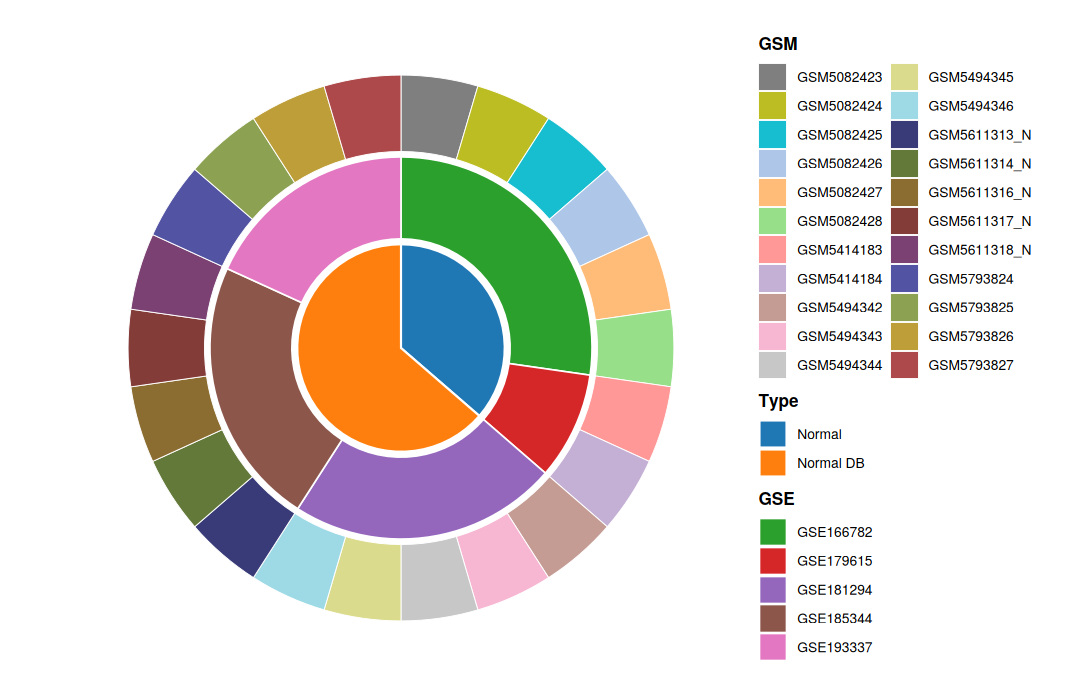

In [9]:
## A 一张旭日：内环 Type，中环 GSE，外环 GSM。字不写进图，三项都进图例。颜色互不重复。
sun <- samp[type %in% c("Normal", "Normal_DB")]
sun[, type_l := factor(type_lab[type], levels = c("Normal", "Normal DB"))]
setorder(sun, type_l, GSE.ID, sample.ID)
n <- nrow(sun)
sun[, xmax := seq_len(n) / n]
sun[, xmin := xmax - 1 / n]
type_r <- sun[, .(xmin = min(xmin), xmax = max(xmax), n = .N), by = type_l]
gse_r <- sun[, .(xmin = min(xmin), xmax = max(xmax), n = .N), by = .(type_l, GSE.ID)]
gse_r[, GSE.ID := factor(GSE.ID, levels = unique(as.character(sun$GSE.ID)))]
sun[, sample.ID := factor(sample.ID, levels = as.character(sample.ID))]
pal <- unique(c(substr(pal_d3("category20")(20), 1, 7),
                substr(pal_d3("category20b")(20), 1, 7)))
gse_ids <- levels(gse_r$GSE.ID)
gsm_ids <- levels(sun$sample.ID)
cols_type2 <- setNames(pal[1:2], c("Normal", "Normal DB"))
cols_gse <- setNames(pal[2 + seq_along(gse_ids)], gse_ids)
cols_gsm <- setNames(pal[2 + length(gse_ids) + seq_along(gsm_ids)], gsm_ids)
p_a <- ggplot() +
  geom_rect(data = type_r,
            aes(xmin = xmin, xmax = xmax, ymin = 0, ymax = 0.38, fill = type_l),
            color = "white", linewidth = 0.45) +
  scale_fill_manual(name = "Type", values = cols_type2) +
  new_scale_fill() +
  geom_rect(data = gse_r,
            aes(xmin = xmin, xmax = xmax, ymin = 0.40, ymax = 0.70, fill = GSE.ID),
            color = "white", linewidth = 0.35) +
  scale_fill_manual(name = "GSE", values = cols_gse) +
  new_scale_fill() +
  geom_rect(data = sun,
            aes(xmin = xmin, xmax = xmax, ymin = 0.72, ymax = 1.00, fill = sample.ID),
            color = "white", linewidth = 0.2) +
  scale_fill_manual(name = "GSM", values = cols_gsm) +
  coord_polar(theta = "x") +
  ylim(0, 1.02) + theme_void(base_size = 12) +
  theme(legend.position = "right",
        legend.text = element_text(size = 8),
        legend.title = element_text(size = 10, face = "bold"))
options(repr.plot.width = 9.0, repr.plot.height = 5.8)
p_a

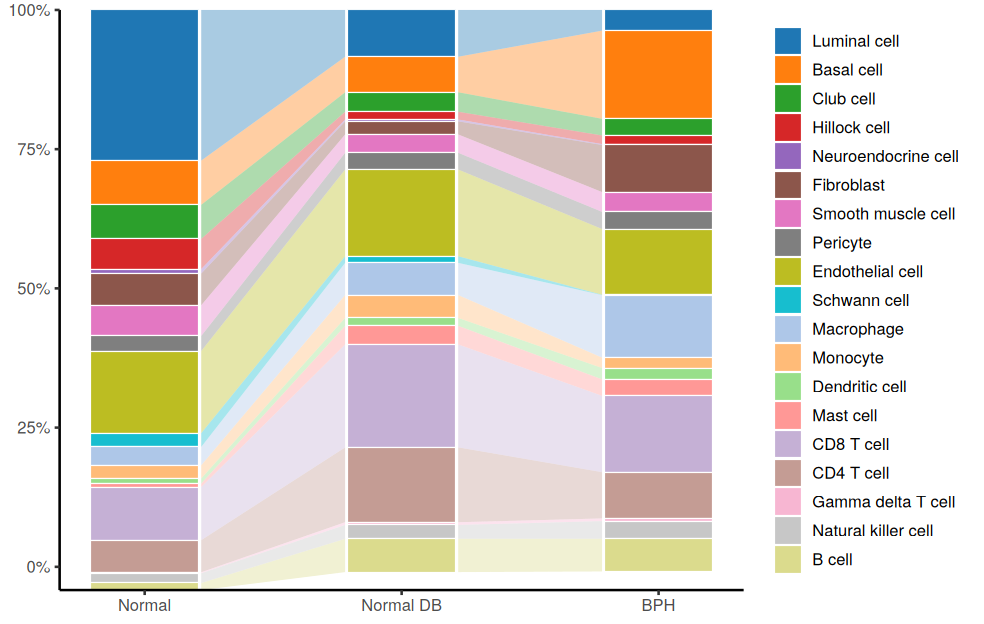

In [ ]:
## C 组成堆叠：样本均值，全组织分母。全部 H2 原名，不合并 Other。
obs3 <- obs[type %in% type3]
h2_lv <- c(
  "Luminal cell", "Basal cell", "Club cell", "Hillock cell", "Neuroendocrine cell",
  "Fibroblast", "Smooth muscle cell", "Pericyte", "Endothelial cell", "Schwann cell",
  "Macrophage", "Monocyte", "Dendritic cell", "Mast cell",
  "CD8 T cell", "CD4 T cell", "Gamma delta T cell", "Natural killer cell", "B cell"
)
h2_lv <- intersect(h2_lv, unique(as.character(obs3$celltype_manual_H2)))
st <- obs3[, .(n = .N), by = .(sample.ID, h2s = celltype_manual_H2)]
st <- merge(st, samp, by = "sample.ID")
st[, frac := n / sum(n), by = sample.ID]
st_m <- st[, .(frac = mean(frac), n_samp = uniqueN(sample.ID)), by = .(type, h2s)]
d <- as.data.frame(st_m)
d$h2s <- factor(d$h2s, levels = h2_lv)
d$type <- factor(d$type, levels = type3)
d <- tidyr::complete(d, type, h2s, fill = list(frac = 0, n_samp = 0))
d$h2s <- factor(d$h2s, levels = h2_lv)
d$type <- factor(d$type, levels = type3)
d <- d %>% dplyr::group_by(type) %>% dplyr::arrange(h2s, .by_group = TRUE) %>%
  dplyr::mutate(ymax = 1 - lag(cumsum(frac), default = 0),
                ymin = ymax - frac, x = as.numeric(type))
rib <- do.call(rbind, lapply(seq_len(length(type3) - 1), function(i) {
  a <- subset(d, x == i); b <- subset(d, x == i + 1)
  do.call(rbind, lapply(h2_lv, function(ctn) {
    aa <- a[a$h2s == ctn, ]; bb <- b[b$h2s == ctn, ]
    data.frame(id = paste(i, ctn), h2s = ctn,
               x = c(i + .22, i + 1 - .22, i + 1 - .22, i + .22),
               y = c(aa$ymax, bb$ymax, bb$ymin, aa$ymin))
  }))
}))
cols_h2_all <- setNames(substr(pal_d3("category20")(length(h2_lv)), 1, 7), h2_lv)
p_b <- ggplot() +
  geom_polygon(data = rib, aes(x, y, group = id, fill = h2s), alpha = .38, color = NA) +
  geom_rect(data = d, aes(xmin = x - .21, xmax = x + .21,
                          ymin = ymin, ymax = ymax, fill = h2s),
            color = "white", linewidth = .25) +
  scale_fill_manual(values = cols_h2_all) +
  scale_x_continuous(breaks = seq_along(type3), labels = unname(type_lab[type3])) +
  scale_y_continuous(expand = c(0, 0), labels = percent_format()) +
  th + labs(x = NULL, y = NULL)
options(repr.plot.width = 8.2, repr.plot.height = 5.2)
p_b

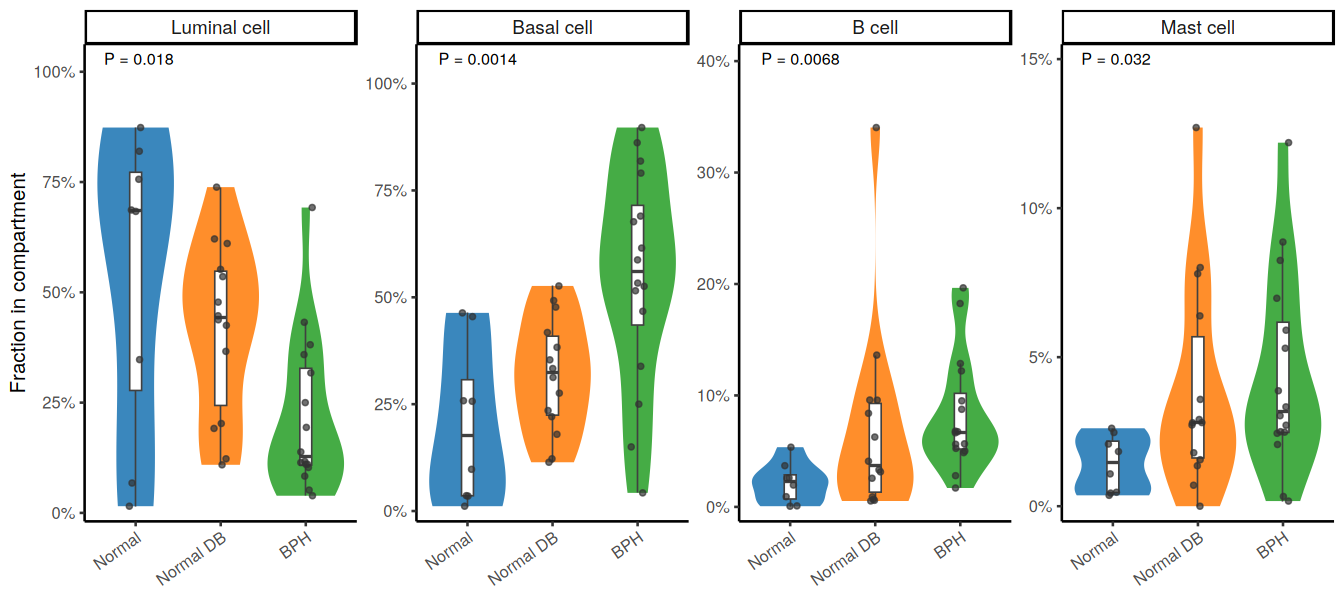

In [48]:
## D 隔室内部比。上皮 Luminal/Basal，微环境 B/Mast。标题用 H2 原名。一个 KW p。
h2_lab <- function(x) as.character(x)
plot_h2_kw <- function(vals, ncol, width, height, ylab) {
  feat <- data.table(val = vals, lab = h2_lab(vals))
  box <- rbindlist(lapply(seq_len(nrow(feat)), function(i) {
    x <- frac_in_comp("celltype_manual_H2", feat$val[i], type3)
    x[, feature := feat$lab[i]]
    x
  }))
  box[, type := factor(type, levels = type3)]
  box[, feature := factor(as.character(feature), levels = feat$lab)]
  ann <- box[, {
    p <- kw_p(frac, type)
    .(labp = sprintf("P = %s", formatC(p, format = "g", digits = 2)))
  }, by = feature]
  ggplot(box, aes(type, frac, fill = type)) +
    geom_violin(scale = "width", trim = TRUE, color = NA, alpha = 0.88, width = 0.9) +
    geom_boxplot(width = 0.14, outlier.shape = NA, fill = "white",
                 color = "grey25", linewidth = 0.35) +
    geom_jitter(width = 0.08, size = 1.1, alpha = 0.7, color = "grey20") +
    geom_text(data = ann, aes(label = labp),
              inherit.aes = FALSE, x = -Inf, y = Inf,
              hjust = -0.28, vjust = 1.7, size = 3.3) +
    facet_wrap(~ feature, ncol = ncol, scales = "free_y") +
    scale_fill_manual(values = cols_type, labels = type_lab, guide = "none") +
    scale_x_discrete(labels = type_lab[type3]) +
    scale_y_continuous(labels = percent_format(accuracy = 1),
                       expand = expansion(mult = c(0.04, 0.22))) +
    th + theme(axis.text.x = element_text(angle = 35, hjust = 1),
               strip.text = element_text(size = 11)) +
    labs(x = NULL, y = ylab)
}
p_d <- plot_h2_kw(
  c("Luminal cell", "Basal cell", "B cell", "Mast cell"),
  ncol = 4, width = 11.2, height = 5.0,
  ylab = "Fraction in compartment"
)
options(repr.plot.width = 11.2, repr.plot.height = 5.0)
p_d


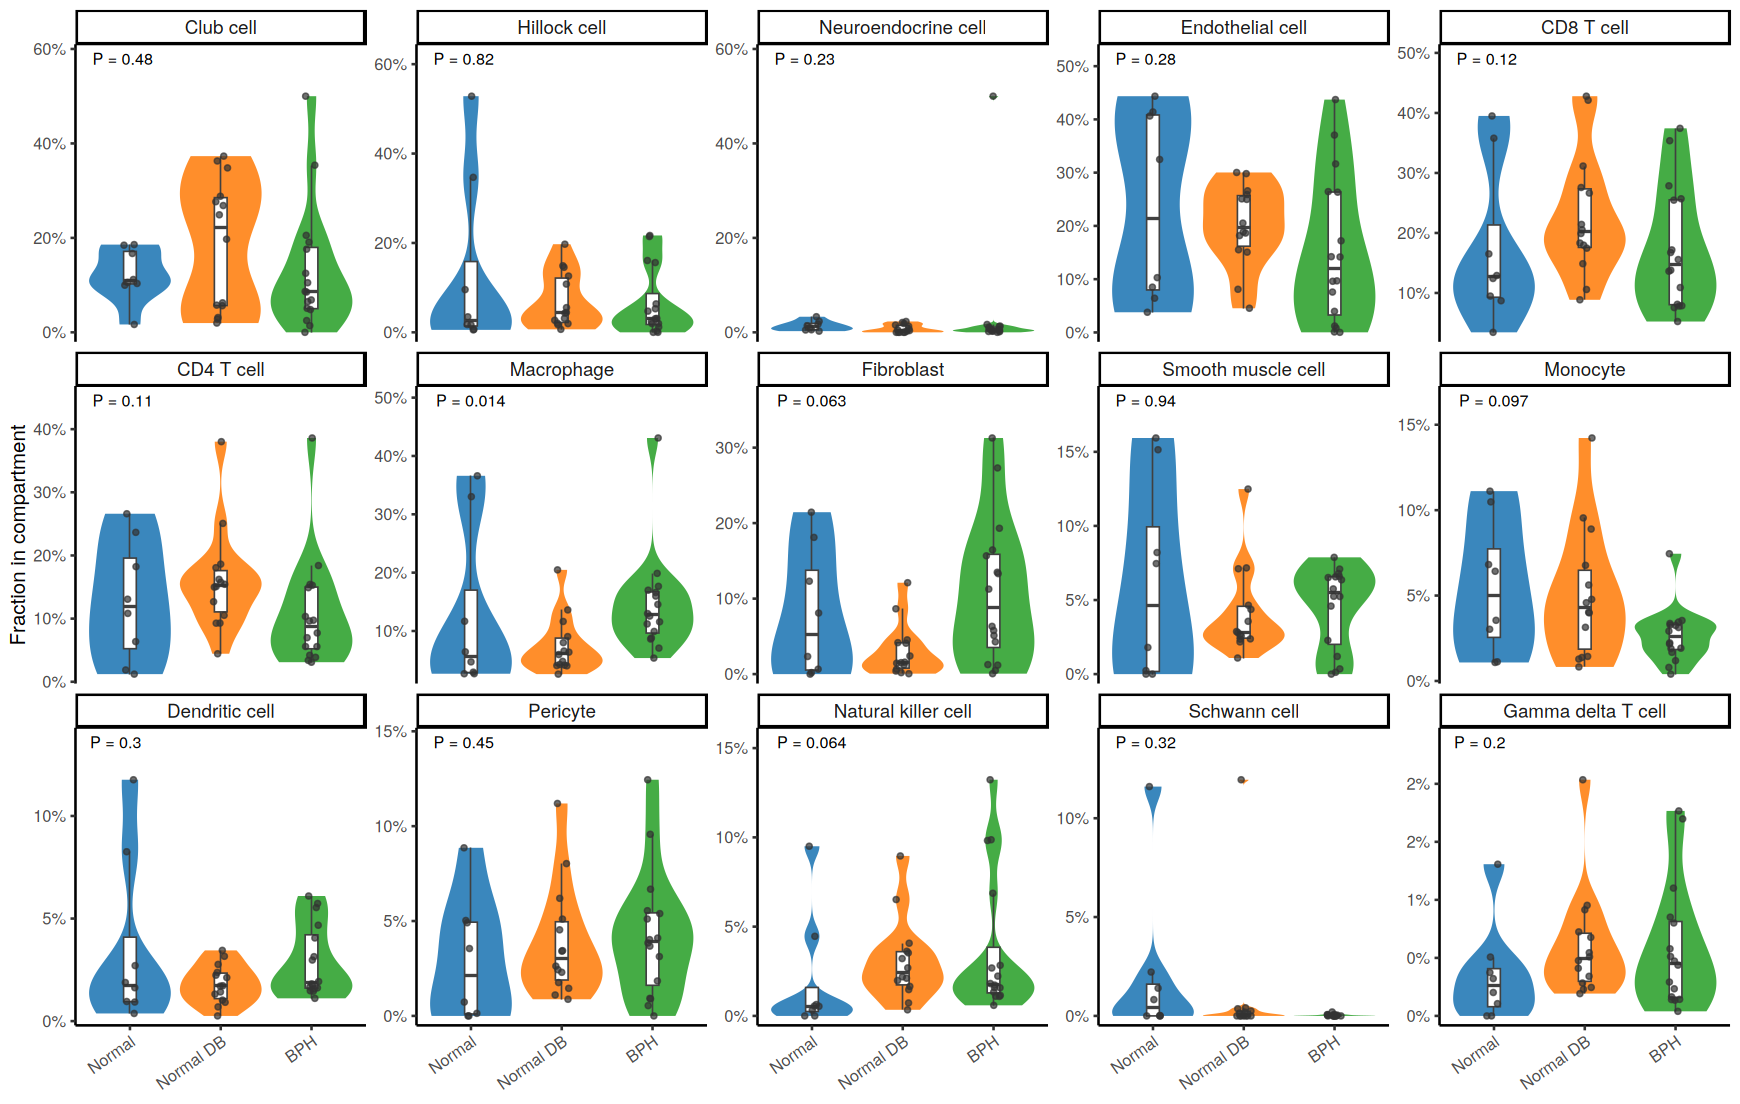

In [49]:
## E 其余全部 H2，隔室内部比。标题用 H2 原名。一个 KW p。
h2_rest <- c(
  "Club cell", "Hillock cell", "Neuroendocrine cell",
  "Endothelial cell", "CD8 T cell", "CD4 T cell",
  "Macrophage", "Fibroblast", "Smooth muscle cell",
  "Monocyte", "Dendritic cell", "Pericyte",
  "Natural killer cell", "Schwann cell", "Gamma delta T cell"
)
p_e <- plot_h2_kw(h2_rest, ncol = 5, width = 14.5, height = 9.2,
                  ylab = "Fraction in compartment")
options(repr.plot.width = 14.5, repr.plot.height = 9.2)
p_e


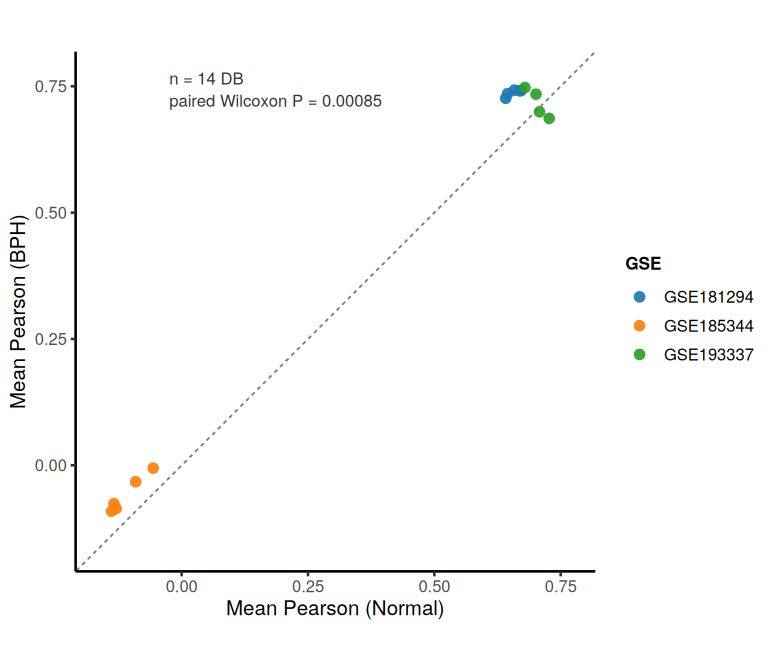

In [50]:
## B PAM50 式：14 个 DB 为点。x=mean Pearson vs Normal，y=mean Pearson vs BPH。
## 虚线 y=x；线上=更像 BPH。点按 GSE 着色。
db <- fread(file.path(outd, "corr_db_vs_NB.csv"))
stopifnot(nrow(db) == 14L)
gse_lv <- c("GSE181294", "GSE185344", "GSE193337")
db[, gse_l := factor(GSE.ID, levels = gse_lv)]
pw <- wilcox.test(db$r_BPH, db$r_Normal, paired = TRUE, exact = TRUE)
lim <- range(c(db$r_Normal, db$r_BPH), na.rm = TRUE)
pad <- diff(lim) * 0.08
lim <- c(lim[1] - pad, lim[2] + pad)
cols_gse_f <- setNames(substr(pal_d3("category20")(3), 1, 7), gse_lv)
ann <- sprintf("n = %d DB\npaired Wilcoxon P = %.2g",
               nrow(db), pw$p.value)
p_f <- ggplot(db, aes(r_Normal, r_BPH, color = gse_l)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed",
              colour = "grey50", linewidth = 0.4) +
  geom_point(size = 3.0, alpha = 0.92, stroke = 0) +
  annotate("text",
           x = lim[1] + diff(lim) * 0.18,
           y = lim[2] - diff(lim) * 0.04,
           label = ann, hjust = 0, vjust = 1, size = 3.4,
           color = "grey20", lineheight = 1.15) +
  scale_color_manual(values = cols_gse_f, name = "GSE") +
  coord_equal(xlim = lim, ylim = lim, expand = FALSE) +
  th + theme(legend.title = element_text(size = 10, face = "bold")) +
  labs(x = "Mean Pearson (Normal)",
       y = "Mean Pearson (BPH)")
options(repr.plot.width = 6.4, repr.plot.height = 5.6)
p_f

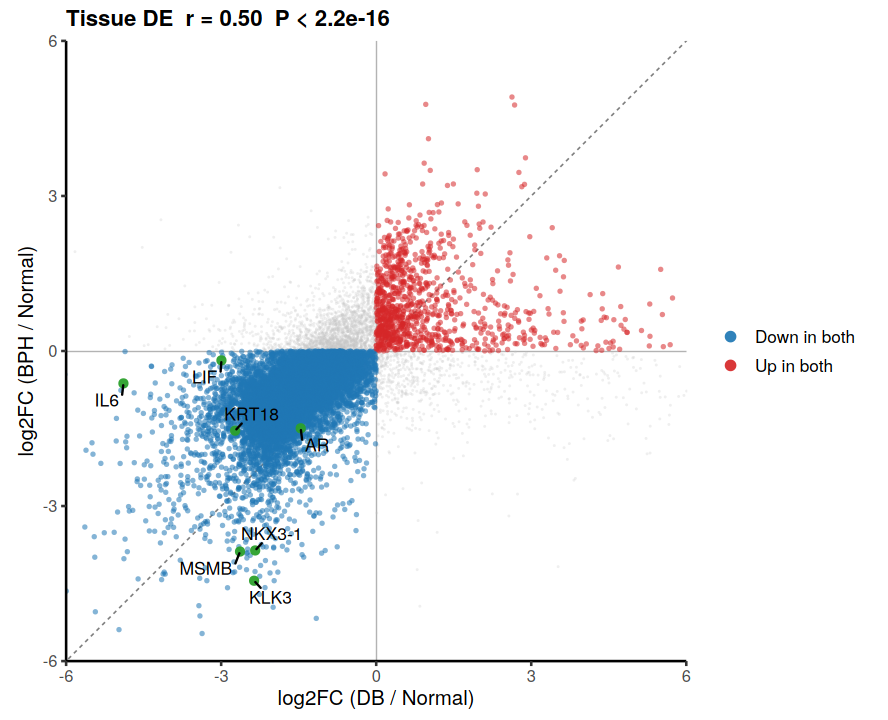

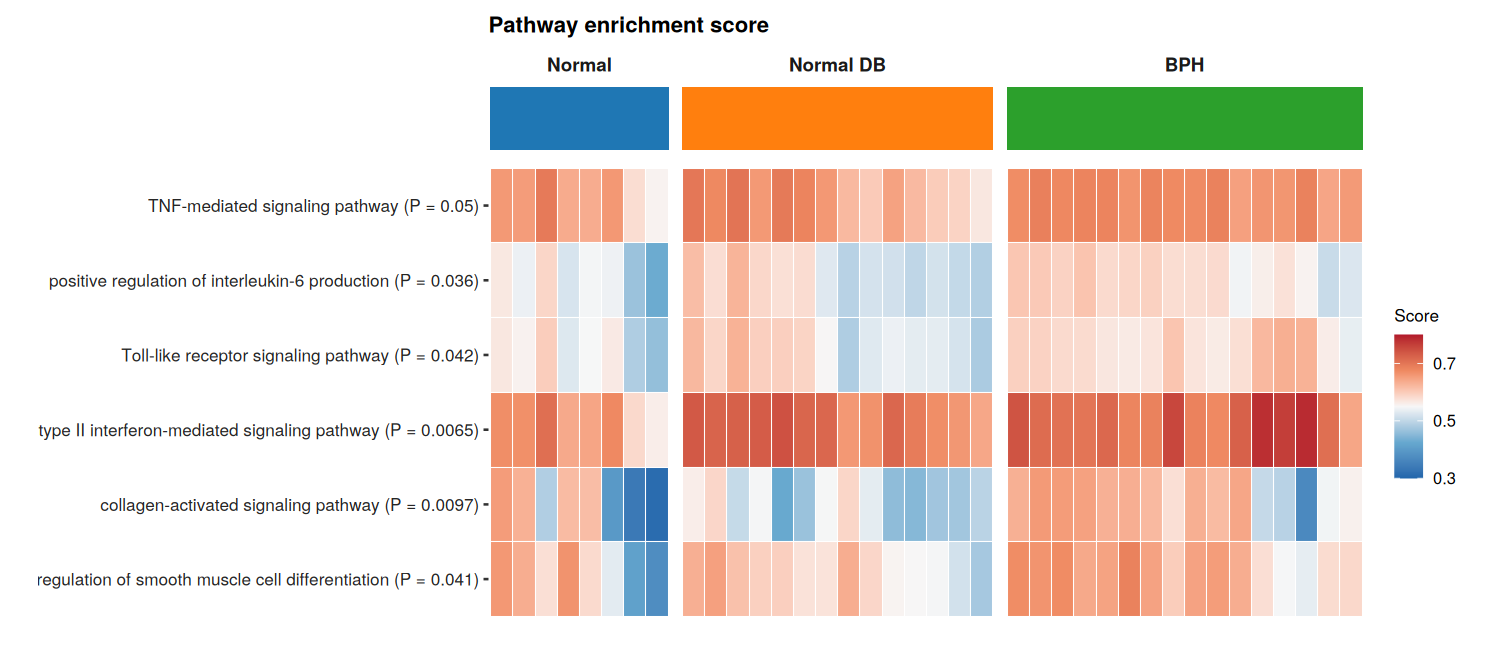

In [67]:
## F1 全组织伪 bulk DE：点=基因。横轴 log2FC(DB/N)，纵轴 log2FC(BPH/N)。
## 相关=这两条 logFC 向量的 Pearson（基因之间，不是样本之间）。
## 同向下降蓝、同向上升红；关键基因且同向：放大+绿。两张图分开画。
de <- fread(file.path(outd, "de_allcell_vs_Normal.csv"))
de <- de[!grepl("^ENSG", gene)]
de[, same := (sign(lfc_DB) == sign(lfc_BPH)) & (lfc_DB != 0) & (lfc_BPH != 0)]
de[, dir := fifelse(!same, "opposite",
                    fifelse(lfc_DB < 0, "down", "up"))]
mark <- c("KLK3", "MSMB", "NKX3-1", "AR", "KRT18", "KRT14", "IL6", "LIF")
de[, key := gene %in% mark & same]
ct <- suppressWarnings(cor.test(de$lfc_DB, de$lfc_BPH, method = "pearson"))
rr <- unname(ct$estimate)
pp <- ct$p.value
p_f1 <- ggplot(de, aes(lfc_DB, lfc_BPH)) +
  geom_hline(yintercept = 0, colour = "grey70", linewidth = 0.3) +
  geom_vline(xintercept = 0, colour = "grey70", linewidth = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed",
              colour = "grey50", linewidth = 0.35) +
  geom_point(data = de[key == FALSE & dir == "opposite"], aes(color = dir),
             size = 0.55, alpha = 0.28, stroke = 0) +
  geom_point(data = de[key == FALSE & dir != "opposite"], aes(color = dir),
             size = 1.25, alpha = 0.55, stroke = 0) +
  geom_point(data = de[key == TRUE], color = "#2CA02C",
             size = 2.6, alpha = 0.95, stroke = 0) +
  ggrepel::geom_text_repel(
    data = de[key == TRUE], aes(label = gene),
    size = 3.6, colour = "black", fontface = "plain",
    min.segment.length = 0.15, box.padding = 0.35,
    max.overlaps = Inf, seed = 1
  ) +
  scale_color_manual(
    values = c(down = "#1F77B4", up = "#D62728", opposite = "grey78"),
    breaks = c("down", "up"),
    labels = c("Down in both", "Up in both"),
    name = NULL
  ) +
  coord_equal(xlim = c(-6, 6), ylim = c(-6, 6), expand = FALSE) +
  guides(color = guide_legend(
    override.aes = list(size = 3.0, alpha = 0.92, stroke = 0))) +
  th + theme(legend.position = "right",
             legend.text = element_text(size = 10),
             legend.title = element_blank()) +
  labs(x = "log2FC (DB / Normal)", y = "log2FC (BPH / Normal)",
       title = sprintf(
         "Tissue DE  r = %.2f  %s",
         rr,
         ifelse(pp < 2.2e-16, "P < 2.2e-16",
                sprintf("P = %s", formatC(pp, format = "g", digits = 2)))
       ))
options(repr.plot.width = 7.4, repr.plot.height = 6.0)
p_f1

## F2 热图：原始秩次富集分（不用 z，无负数）。通路名后加 KW P。
sc_l <- fread(file.path(outd, "pathway_allcell_rank_sel.csv"))
pw_lv <- c(
  "TNF-mediated signaling pathway",
  "positive regulation of\ninterleukin-6 production",
  "Toll-like receptor\nsignaling pathway",
  "type II interferon-mediated\nsignaling pathway",
  "collagen-activated\nsignaling pathway",
  "regulation of smooth muscle\ncell differentiation"
)
sc_l[, pw := factor(pw, levels = pw_lv)]
sc_l[, type := factor(type, levels = type3)]
ann_f <- sc_l[, {
  p <- kw_p(score, type)
  plab <- ifelse(p < 2.2e-16, "P < 2.2e-16",
                 sprintf("P = %s", formatC(p, format = "g", digits = 2)))
  .(ylab = paste0(gsub("\n", " ", pw[1]), " (", plab, ")"), p = p)
}, by = pw]
ann_f[, ylab := factor(ylab, levels = rev(ylab))]
sc_l <- merge(sc_l, ann_f[, .(pw, ylab)], by = "pw")
ord <- sc_l[, .(m = mean(score)), by = .(type, sample.ID)]
setorder(ord, type, -m)
sc_l[, sid := factor(sample.ID, levels = ord$sample.ID)]
p_ann <- ggplot(unique(sc_l[, .(sid, type)]), aes(sid, " ", fill = type)) +
  geom_tile() +
  facet_grid(. ~ type, scales = "free_x", space = "free_x",
             labeller = labeller(type = type_lab)) +
  scale_fill_manual(values = cols_type, guide = "none") +
  th + theme(axis.title = element_blank(), axis.text = element_blank(),
             axis.ticks = element_blank(), axis.line = element_blank(),
             strip.background = element_blank(),
             strip.text = element_text(face = "bold", size = 11),
             plot.margin = margin(4, 8, 0, 8)) +
  labs(title = "Pathway enrichment score")
p_hm <- ggplot(sc_l, aes(sid, ylab, fill = score)) +
  geom_tile(color = "white", linewidth = 0.22) +
  facet_grid(. ~ type, scales = "free_x", space = "free_x") +
  scale_fill_gradientn(
    colours = c("#2166AC", "#67A9CF", "#F7F7F7", "#EF8A62", "#B2182B"),
    limits = c(0.30, 0.80), oob = scales::squish,
    breaks = c(0.3, 0.5, 0.7), name = "Score"
  ) +
  th + theme(axis.title = element_blank(),
             axis.text.x = element_blank(), axis.ticks.x = element_blank(),
             axis.line = element_blank(),
             axis.text.y = element_text(size = 10, color = "grey15"),
             strip.text = element_blank(), strip.background = element_blank(),
             legend.title = element_text(size = 10),
             plot.margin = margin(0, 8, 6, 8)) +
  labs(x = NULL, y = NULL)
p_f2 <- p_ann / p_hm + plot_layout(heights = c(0.16, 1))
options(repr.plot.width = 12.4, repr.plot.height = 5.4)
p_f2